<a href="https://colab.research.google.com/github/Rohim110606/BigData26_A_2411533015_Abdur-Rohim/blob/main/Praktikum1/BD_A_p01_2411533015_Abdur_Rohim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A.KODINGAN PRAKTIKUM

In [ ]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [ ]:
!free -h         # kapasitas dan sisa RAM
!df -h /content  # kapasitas dan sisa disk runtime
!java -version   # dibutuhkan PySpark pada langkah K-8

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.3Gi       8.5Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.024s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.024s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [ ]:
from google.colab import drive
drive.mount("/content/drive")         # ikuti dialog izin yang muncul

import os
DIR_KERJA  = "/content/data"                         # sementara, cepat
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1" # permanen
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'grafik_yellow_taxi.png', 'pengukuran_kinerja.csv']


In [ ]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []        # menyimpan hasil pengukuran untuk dibandingkan nanti

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil  = fungsi()
    detik  = time.perf_counter() - t0
    delta  = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

In [ ]:
import urllib.request

URL  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.43 s | RSS +1.9 MB
Ukuran file: 45.5 MB


In [ ]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris  : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [ ]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh                                # bebaskan memori sebelum percobaan kedua
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 2.23 s | RSS +496.2 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.70 s | RSS +208.4 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [ ]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2   # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]   = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"           : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"          : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"   : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"    : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [ ]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


In [ ]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")


def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 40.18 s | RSS +5.3 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 5.06 s | RSS +20.1 MB
2,986,911 baris | rata-rata total_amount = 27.33


In [ ]:
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

# Membuat sesi Spark lokal
spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")                  # menggunakan semua core mesin ini
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

# Memuat data dan inspeksi awal
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))


sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("timestamp").cast("long")
        - F.col("tpep_pickup_datetime").cast("timestamp").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))


hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                    AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 16.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.030s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.030s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spa

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


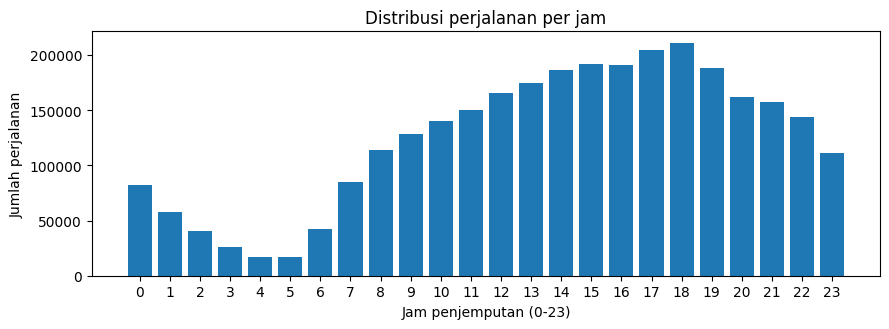

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

STUDI KASUS

In [ ]:
# 1. Tambahkan dimensi hari
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()

# True = Sabtu/Minggu, False = hari kerja
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5

# Tarif per menit sesuai instruksi studi kasus
bersih["tarif_per_menit"] = (
    bersih["total_amount"] / bersih["durasi_menit"]
).round(3)

In [ ]:
ringkas = (
    bersih
    .assign(jam=bersih["tpep_pickup_datetime"].dt.hour)
    .groupby(["akhir_pekan", "jam"])
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
    .reset_index()
)

print(" RINGKASAN AKHIR PEKAN VS HARI KERJA ")
display(ringkas)

 RINGKASAN AKHIR PEKAN VS HARI KERJA 


,akhir_pekan,jam,jumlah_perjalanan,rata_durasi,rata_tarif,rata_tarif_per_menit
0,False,0,35351,14.10,33.509998,2.57
1,False,1,17516,13.04,31.080000,2.66
2,False,2,9452,12.23,27.690001,2.63
3,False,3,6238,12.87,30.940001,2.72
4,False,4,6192,14.79,37.990002,2.81
5,False,5,12462,14.63,36.270000,2.82
6,False,6,35728,14.57,29.400000,2.33
7,False,7,74157,14.66,25.959999,2.07
8,False,8,98431,14.82,24.809999,1.90
9,False,9,103263,15.03,25.639999,1.90


In [ ]:
per_jam = (
    bersih
    .assign(jam=bersih["tpep_pickup_datetime"].dt.hour)
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
    .reset_index()
)

jam_tertinggi = per_jam.loc[
    per_jam["jumlah_perjalanan"].idxmax()
]

jam_terendah = per_jam.loc[
    per_jam["jumlah_perjalanan"].idxmin()
]

print("\n PERTANYAAN 1 ")
print(
    f"Permintaan tertinggi: jam {int(jam_tertinggi['jam']):02d}.00 "
    f"dengan {int(jam_tertinggi['jumlah_perjalanan']):,} perjalanan."
)

print(
    f"Permintaan terendah: jam {int(jam_terendah['jam']):02d}.00 "
    f"dengan {int(jam_terendah['jumlah_perjalanan']):,} perjalanan."
)


 PERTANYAAN 1 
Permintaan tertinggi: jam 18.00 dengan 210,858 perjalanan.
Permintaan terendah: jam 04.00 dengan 16,618 perjalanan.


In [ ]:
weekday = ringkas[ringkas["akhir_pekan"] == False].copy()
weekend = ringkas[ringkas["akhir_pekan"] == True].copy()

# Jam dengan permintaan tertinggi untuk masing-masing kelompok
puncak_weekday = weekday.loc[
    weekday["jumlah_perjalanan"].idxmax()
]

puncak_weekend = weekend.loc[
    weekend["jumlah_perjalanan"].idxmax()
]

print("\n PERTANYAAN 2 ")
print(
    f"Hari kerja mencapai puncak pada jam {int(puncak_weekday['jam']):02d}.00 "
    f"dengan {int(puncak_weekday['jumlah_perjalanan']):,} perjalanan."
)

print(
    f"Akhir pekan mencapai puncak pada jam {int(puncak_weekend['jam']):02d}.00 "
    f"dengan {int(puncak_weekend['jumlah_perjalanan']):,} perjalanan."
)


 PERTANYAAN 2 
Hari kerja mencapai puncak pada jam 18.00 dengan 159,457 perjalanan.
Akhir pekan mencapai puncak pada jam 16.00 dengan 54,057 perjalanan.


In [ ]:
# Jam sibuk didefinisikan sebagai jam dengan jumlah perjalanan tertinggi
jam_sibuk = int(jam_tertinggi["jam"])

sibuk = per_jam[per_jam["jam"] == jam_sibuk].iloc[0]
jam_lain = per_jam[per_jam["jam"] != jam_sibuk]

perbandingan_lain = {
    "rata_durasi": jam_lain["rata_durasi"].mean(),
    "rata_tarif_per_menit": jam_lain["rata_tarif_per_menit"].mean()
}

durasi_sibuk = sibuk["rata_durasi"]
tarif_menit_sibuk = sibuk["rata_tarif_per_menit"]

durasi_lain = perbandingan_lain["rata_durasi"]
tarif_menit_lain = perbandingan_lain["rata_tarif_per_menit"]

lebih_pendek = durasi_sibuk < durasi_lain
lebih_menguntungkan = tarif_menit_sibuk > tarif_menit_lain

print("\n PERTANYAAN 3 ")
print(
    f"Jam sibuk = {jam_sibuk:02d}.00 | "
    f"durasi rata-rata {durasi_sibuk:.2f} menit | "
    f"tarif/menit {tarif_menit_sibuk:.3f}"
)

print(
    f"Jam lain = durasi rata-rata {durasi_lain:.2f} menit | "
    f"tarif/menit {tarif_menit_lain:.3f}"
)

if lebih_pendek and lebih_menguntungkan:
    print("Kesimpulan: BENAR, jam sibuk lebih pendek dan lebih menguntungkan per menit.")
elif lebih_pendek:
    print("Kesimpulan: jam sibuk lebih pendek, tetapi tidak lebih menguntungkan per menit.")
elif lebih_menguntungkan:
    print("Kesimpulan: jam sibuk lebih menguntungkan per menit, tetapi tidak lebih pendek.")
else:
    print("Kesimpulan: klaim tersebut TIDAK terbukti.")


 PERTANYAAN 3 
Jam sibuk = 18.00 | durasi rata-rata 14.24 menit | tarif/menit 2.150
Jam lain = durasi rata-rata 14.23 menit | tarif/menit 2.211
Kesimpulan: klaim tersebut TIDAK terbukti.


In [ ]:
tabel_jawaban = pd.DataFrame({
    "Pertanyaan": [
        "1. Permintaan tertinggi",
        "1. Permintaan terendah",
        "2. Puncak hari kerja",
        "2. Puncak akhir pekan",
        "3. Jam sibuk: durasi rata-rata",
        "3. Jam sibuk: tarif/menit",
        "3. Jam lain: durasi rata-rata",
        "3. Jam lain: tarif/menit"
    ],
    "Nilai": [
        f"{int(jam_tertinggi['jam']):02d}.00 ({int(jam_tertinggi['jumlah_perjalanan']):,} perjalanan)",
        f"{int(jam_terendah['jam']):02d}.00 ({int(jam_terendah['jumlah_perjalanan']):,} perjalanan)",
        f"{int(puncak_weekday['jam']):02d}.00 ({int(puncak_weekday['jumlah_perjalanan']):,})",
        f"{int(puncak_weekend['jam']):02d}.00 ({int(puncak_weekend['jumlah_perjalanan']):,})",
        f"{durasi_sibuk:.2f} menit",
        f"{tarif_menit_sibuk:.3f}",
        f"{durasi_lain:.2f} menit",
        f"{tarif_menit_lain:.3f}"
    ]
})

display(tabel_jawaban)

,Pertanyaan,Nilai
0,1. Permintaan tertinggi,"18.00 (210,858 perjalanan)"
1,1. Permintaan terendah,"04.00 (16,618 perjalanan)"
2,2. Puncak hari kerja,"18.00 (159,457)"
3,2. Puncak akhir pekan,"16.00 (54,057)"
4,3. Jam sibuk: durasi rata-rata,14.24 menit
5,3. Jam sibuk: tarif/menit,2.150
6,3. Jam lain: durasi rata-rata,14.23 menit
7,3. Jam lain: tarif/menit,2.211


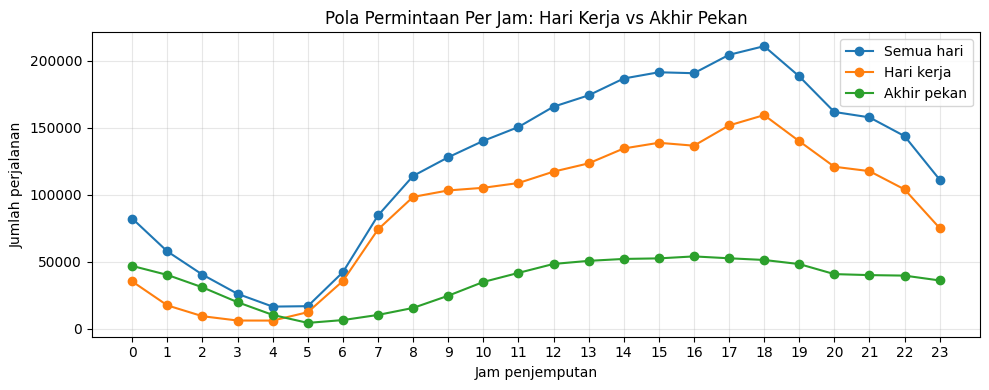

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    per_jam["jam"],
    per_jam["jumlah_perjalanan"],
    marker="o",
    label="Semua hari"
)

plt.plot(
    weekday["jam"],
    weekday["jumlah_perjalanan"],
    marker="o",
    label="Hari kerja"
)

plt.plot(
    weekend["jam"],
    weekend["jumlah_perjalanan"],
    marker="o",
    label="Akhir pekan"
)

plt.xlabel("Jam penjemputan")
plt.ylabel("Jumlah perjalanan")
plt.title("Pola Permintaan Per Jam: Hari Kerja vs Akhir Pekan")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

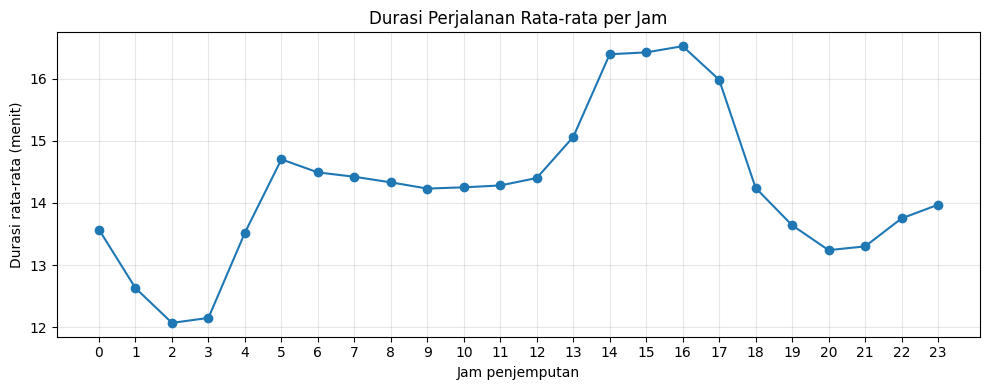

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    per_jam["jam"],
    per_jam["rata_durasi"],
    marker="o",
    label="Rata-rata durasi (menit)"
)

plt.xlabel("Jam penjemputan")
plt.ylabel("Durasi rata-rata (menit)")
plt.title("Durasi Perjalanan Rata-rata per Jam")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

LATIHAN 1

In [ ]:
# LATIHAN 1 - 5 trip_distance terbesar

top5_jarak = (
    bersih
    .nlargest(5, "trip_distance")
)

print("=== 5 TRIP_DISTANCE TERBESAR ===")
display(top5_jarak)

=== 5 TRIP_DISTANCE TERBESAR ===


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


LATIHAN 2

In [ ]:
# LATIHAN 2 - Perbandingan chunksize

hasil_chunk_100k = ukur(
    "agregasi chunking 100k",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000)
)

hasil_chunk_1m = ukur(
    "agregasi chunking 1m",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000)
)

print("\n=== HASIL ===")
print(
    "chunksize 100.000:",
    hasil_chunk_100k[0],
    "baris | total:",
    hasil_chunk_100k[1]
)

print(
    "chunksize 1.000.000:",
    hasil_chunk_1m[0],
    "baris | total:",
    hasil_chunk_1m[1]
)

# Ambil catatan performa yang baru saja ditambahkan
perbandingan_chunk = pd.DataFrame(catatan).tail(2)

display(perbandingan_chunk)

[agregasi chunking 100k] 4.16 s | RSS +58.4 MB
[agregasi chunking 1m] 6.00 s | RSS +18.8 MB

=== HASIL ===
chunksize 100.000: 2986911 baris | total: 81621456.74000004
chunksize 1.000.000: 2986911 baris | total: 81621456.73999998


,langkah,detik,delta_rss_mb
7,agregasi chunking 100k,4.16,58.4
8,agregasi chunking 1m,6.00,18.8


LATIHAN 3

In [ ]:
# LATIHAN 3 - Persentase tip per payment_type

import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] != 0,
    (bersih["tip_amount"] / bersih["fare_amount"]) * 100,
    np.nan
)

rata_persen_tip = (
    bersih
    .groupby("payment_type", observed=True)
    .agg(
        rata_persen_tip=("persen_tip", "mean"),
        jumlah_transaksi=("persen_tip", "count"),
        fare_nol=( "fare_amount", lambda x: (x == 0).sum())
    )
    .round(2)
    .reset_index()
)

print("=== RATA-RATA PERSEN TIP PER PAYMENT_TYPE ===")
display(rata_persen_tip)

=== RATA-RATA PERSEN TIP PER PAYMENT_TYPE ===


,payment_type,rata_persen_tip,jumlah_transaksi,fare_nol
0,0,20.219999,64106,0
1,1,25.910000,2385053,11
2,2,0.000000,512885,102
3,3,0.020000,9145,39
4,4,0.150000,15542,28


LATIHAN 4

In [ ]:
# LATIHAN 4 - Perbandingan Parquet Snappy vs Gzip

PARQUET_SNAPPY = f"{DIR_SIMPAN}/bersih_snappy.parquet"
PARQUET_GZIP   = f"{DIR_SIMPAN}/bersih_gzip.parquet"

# Snappy
ukur(
    "tulis Parquet snappy",
    lambda: bersih.to_parquet(
        PARQUET_SNAPPY,
        index=False,
        compression="snappy"
    )
)

# Gzip
ukur(
    "tulis Parquet gzip",
    lambda: bersih.to_parquet(
        PARQUET_GZIP,
        index=False,
        compression="gzip"
    )
)

ukuran_snappy = os.path.getsize(PARQUET_SNAPPY) / 1024**2
ukuran_gzip = os.path.getsize(PARQUET_GZIP) / 1024**2

print("=== PERBANDINGAN PARQUET ===")
print(f"Snappy : {ukuran_snappy:.2f} MB")
print(f"Gzip   : {ukuran_gzip:.2f} MB")

hasil_kompresi = (
    pd.DataFrame(catatan)
    .query("langkah in ['tulis Parquet snappy', 'tulis Parquet gzip']")
    .copy()
)

hasil_kompresi["ukuran_mb"] = [
    ukuran_snappy,
    ukuran_gzip
]

display(hasil_kompresi)

[tulis Parquet snappy] 2.49 s | RSS +44.3 MB
[tulis Parquet gzip] 42.29 s | RSS -40.1 MB
=== PERBANDINGAN PARQUET ===
Snappy : 63.31 MB
Gzip   : 50.98 MB


,langkah,detik,delta_rss_mb,ukuran_mb
9,tulis Parquet snappy,2.49,44.3,63.310699
10,tulis Parquet gzip,42.29,-40.1,50.976109


LATIHAN 5

In [ ]:
# LATIHAN 5 - Agregasi J-9 dengan Spark SQL

from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-PS1-Latihan5")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [ ]:
# Baca data Parquet dan lakukan cleaning yang sama seperti J-8

sdf = spark.read.parquet(PATH)

sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp(F.col("tpep_dropoff_datetime"))
            - F.unix_timestamp(F.col("tpep_pickup_datetime"))
        ) / 60
    )
    .filter(
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") < 100)
    )
    .filter(
        (F.col("durasi_menit") >= 1) &
        (F.col("durasi_menit") <= 180)
    )
    .filter(F.col("total_amount") > 0)
)

# Buat temporary view untuk Spark SQL

sdf_bersih.createOrReplaceTempView("trips_bersih")


In [ ]:
# Agregasi J-9 ditulis ulang menggunakan Spark SQL

hasil_sql = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah_perjalanan,
        ROUND(AVG(trip_distance), 2) AS rata_jarak,
        ROUND(AVG(durasi_menit), 2) AS rata_durasi,
        ROUND(AVG(total_amount), 2) AS rata_tarif,
        ROUND(PERCENTILE_APPROX(total_amount, 0.5), 2) AS median_tarif
    FROM trips_bersih
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")


print("\n HASIL SPARK SQL ")
hasil_sql.show(24, truncate=False)

# Ubah hasil Spark SQL menjadi pandas

hasil_sql_pd = hasil_sql.toPandas()



 HASIL SPARK SQL 
+---+-----------------+----------+-----------+----------+------------+
|jam|jumlah_perjalanan|rata_jarak|rata_durasi|rata_tarif|median_tarif|
+---+-----------------+----------+-----------+----------+------------+
|0  |82289            |4.04      |13.57      |28.86     |21.6        |
|1  |57766            |3.53      |12.63      |26.45     |21.2        |
|2  |40445            |3.28      |12.07      |25.06     |20.52       |
|3  |26146            |3.58      |12.15      |26.26     |20.9        |
|4  |16618            |4.79      |13.52      |31.72     |22.7        |
|5  |16940            |6.03      |14.7       |36.75     |22.0        |
|6  |42300            |4.8       |14.49      |30.63     |18.48       |
|7  |84569            |3.69      |14.42      |26.89     |18.48       |
|8  |114064           |3.08      |14.33      |25.21     |19.1        |
|9  |127988           |3.09      |14.23      |25.51     |19.25       |
|10 |140230           |3.13      |14.25      |25.53     |1

In [ ]:
# Bandingkan jumlah perjalanan dengan hasil J-9

perbandingan = (
    agregasi[["jam", "jumlah_perjalanan"]]
    .merge(
        hasil_sql_pd[["jam", "jumlah_perjalanan"]],
        on="jam",
        suffixes=("_pandas", "_spark_sql")
    )
)

perbandingan["selisih"] = (
    perbandingan["jumlah_perjalanan_pandas"]
    - perbandingan["jumlah_perjalanan_spark_sql"]
)

print("\n PERBANDINGAN JUMLAH J-9 vs SPARK SQL")
display(perbandingan)


 PERBANDINGAN JUMLAH J-9 vs SPARK SQL


,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark_sql,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


In [ ]:
# Bukti konsistensi secara terprogram

selisih_maksimum = perbandingan["selisih"].abs().max()

print("Selisih maksimum:", selisih_maksimum)

if selisih_maksimum == 0:
    print("Hasil konsisten: jumlah perjalanan per jam sama.")
else:
    print(
        "Terdapat perbedaan hasil. Sumber perbedaan perlu diperiksa."
    )


# Tutup Spark setelah selesai
spark.stop()

Selisih maksimum: 0
Hasil konsisten: jumlah perjalanan per jam sama.
